# 05 · Del pronóstico a la cantidad a pedir

El proyecto no termina en una predicción. Termina en una **cantidad**, y esa cantidad sale de la
economía del negocio:

$$q^* = \frac{C_u}{C_u + C_o}$$

con $C_u$ el costo de quedarse corto y $C_o$ el de quedarse largo. En perecederos $C_o$ **no**
es capital inmovilizado: es pérdida total al vencimiento.

El modelo se entrena con pérdida cuantílica en ese $q^*$, así que su salida **es** la orden.

## Qué se verifica acá

1. Que el cuantil crítico sea el que minimiza el costo esperado. No afirmado: medido.
2. Que el faltante y el sobrante esperados salgan de la distribución del modelo, no de un
   supuesto de forma.
3. Que el intervalo esté **calibrado**, que es una de las tres métricas de éxito declaradas.
   Acá es donde el proyecto tenía su defecto más grande.

## Encuadre honesto

El cruce entre predicción conformal y newsvendor **no es un aporte original**: que los cuantiles
calibrados sean equivalentes a la solución óptima del newsvendor es un resultado publicado. Lo
que se reivindica es la aplicación de punta a punta.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from blindside import config as cfg
from blindside.data import loaders
from blindside.data import schema as S
from blindside.decision import newsvendor as nv
from blindside.evaluate import metrics as M
from blindside.models.base import quantile_col

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.grid": True, "grid.alpha": 0.25})

print(f"Cu = {cfg.ECONOMICS.cu}  ·  Co = {cfg.ECONOMICS.co}")
print(f"q* = {cfg.ECONOMICS.critical_fraction:.4f}")
print(f"cuantiles entrenados = {cfg.FORECAST.quantiles}")
print(f"cobertura nominal    = {cfg.FORECAST.coverage:.0%}")

Cu = 1.0  ·  Co = 0.6
q* = 0.6250
cuantiles entrenados = (0.05, 0.5, 0.9, 0.95)
cobertura nominal    = 90%


## 1 · El cuantil crítico, y por qué está por encima de la mediana

En perecederos $C_o$ es pérdida total, lo que empujaría $q^*$ hacia abajo. Pero $C_u$ incluye el
margen perdido **más** el costo de servicio — un cliente que no encuentra el producto puede no
volver —, así que en la práctica $q^*$ queda por encima de 0,5 y la orden por encima de la
mediana.

La interfaz expone cuatro ratios en vez de un número único, porque el ratio es un supuesto del
negocio y no un resultado del modelo.

In [2]:
ratios = pd.DataFrame(
    [
        {
            "Co/Cu": r,
            "q*": nv.critical_fraction(cu=1.0, co=r),
            "lectura": "sobrante casi gratis" if r < 0.5 else ("simétrico" if r == 1.0 else "sobrante caro"),
        }
        for r in (0.3, 0.6, 1.0, 1.5)
    ]
)
display(ratios.round(4))
print(f"El proyecto usa Co/Cu = {cfg.ECONOMICS.co / cfg.ECONOMICS.cu:.1f}")

,Co/Cu,q*,lectura
0,0.3,0.7692,sobrante casi gratis
1,0.6,0.6250,sobrante caro
2,1.0,0.5000,simétrico
3,1.5,0.4000,sobrante caro


El proyecto usa Co/Cu = 0.6


## 2 · La esperanza del newsvendor sobre la distribución del modelo

En el backtest el faltante y el sobrante se pueden **contar**, porque hay realización. En
producción el horizonte todavía no pasó: no hay nada que contar.

Lo que sí hay es la distribución predictiva que el modelo emite como grilla de cuantiles, y la
esperanza sobre ella está definida:

$$E[(D-q)^+] = \int_0^1 \max(F^{-1}(u) - q,\ 0)\,du$$

`expected_cost_from_quantiles` la calcula tratando $F^{-1}$ como lineal a tramos. Antes de
usarla conviene verificarla contra un caso con solución cerrada.

In [3]:
# Uniforme(0, 10) descrita por 99 cuantiles. E[(D-q)+] = (10-q)^2 / 20, exacto.
niveles = tuple(round(k / 100, 2) for k in range(1, 100))
uniforme = pd.DataFrame([{quantile_col(q): 10.0 * q for q in niveles}])
uno = cfg.EconomicsConfig(cu=1.0, co=1.0)

filas = []
for q in (2.0, 5.0, 8.0):
    r = nv.expected_cost_from_quantiles(
        uniforme, quantiles=niveles, order=np.array([q]), economics=uno
    )
    filas.append(
        {
            "orden": q,
            "faltante calculado": float(r["expected_shortfall"].iloc[0]),
            "faltante exacto": (10.0 - q) ** 2 / 20.0,
            "media calculada": float(r["expected_demand"].iloc[0]),
        }
    )
display(pd.DataFrame(filas).round(5))
print("La diferencia de ~5e-4 es el sesgo conocido de las colas planas: la grilla")
print("no describe fuera de [0,01 ; 0,99], así que el faltante es una COTA INFERIOR.")

,orden,faltante calculado,faltante exacto,media calculada
0,2.0,3.1995,3.20,5.0
1,5.0,1.2495,1.25,5.0
2,8.0,0.1995,0.20,5.0


La diferencia de ~5e-4 es el sesgo conocido de las colas planas: la grilla
no describe fuera de [0,01 ; 0,99], así que el faltante es una COTA INFERIOR.


### La identidad que hace consistentes los dos números

$(D-q)^+ - (q-D)^+ = D - q$, así que en esperanza también. El sobrante se **deriva** de esa
identidad en vez de integrarse aparte: así los dos números no pueden contradecirse, y eso es un
invariante testeable.

In [4]:
niveles_reales = (0.05, 0.5, 0.625, 0.9, 0.95)
valores = [0.2, 1.0, 1.3, 2.4, 3.1]
grilla = pd.DataFrame([dict(zip([quantile_col(q) for q in niveles_reales], valores, strict=True))])
r = nv.expected_cost_from_quantiles(grilla, quantiles=niveles_reales, order=np.array([1.3]))

display(r.round(6).T.rename(columns={0: "valor"}))
izq = float(r["expected_shortfall"].iloc[0] - r["expected_overage"].iloc[0])
der = float(r["expected_demand"].iloc[0] - 1.3)
print(f"faltante − sobrante = {izq:.10f}")
print(f"E[D] − q            = {der:.10f}")
print(f"identidad se cumple : {abs(izq - der) < 1e-12}")

,valor
expected_demand,1.22500
expected_shortfall,0.31375
expected_overage,0.38875
expected_cost,0.54700
tail_mass,0.05000


faltante − sobrante = -0.0750000000
E[D] − q            = -0.0750000000
identidad se cumple : True


### Y el óptimo cae en q*

Esta es la celda que conecta las dos mitades del proyecto. Si el mínimo del costo esperado no
cayera en $q^*$, la capa de decisión estaría resolviendo otro problema del que dice resolver.

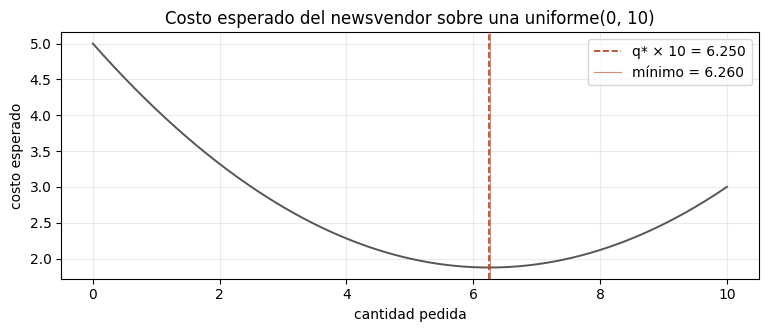

mínimo empírico 6.2600 contra el teórico 6.2500


In [5]:
eco = cfg.ECONOMICS
candidatos = np.linspace(0.0, 10.0, 501)
repetida = pd.concat([uniforme] * len(candidatos), ignore_index=True)
costos = nv.expected_cost_from_quantiles(
    repetida, quantiles=niveles, order=candidatos, economics=eco
)["expected_cost"].to_numpy()

optimo_empirico = float(candidatos[int(np.argmin(costos))])
optimo_teorico = 10.0 * eco.critical_fraction

fig, eje = plt.subplots()
eje.plot(candidatos, costos, color="#5A5550", lw=1.4)
eje.axvline(optimo_teorico, color="#C23D14", ls="--", lw=1.2, label=f"q* × 10 = {optimo_teorico:.3f}")
eje.axvline(optimo_empirico, color="#C23D14", lw=0.8, alpha=0.6, label=f"mínimo = {optimo_empirico:.3f}")
eje.set_xlabel("cantidad pedida")
eje.set_ylabel("costo esperado")
eje.set_title("Costo esperado del newsvendor sobre una uniforme(0, 10)")
eje.legend()
plt.show()

print(f"mínimo empírico {optimo_empirico:.4f} contra el teórico {optimo_teorico:.4f}")

## 3 · El intervalo: donde el proyecto tenía su defecto más grande

La cobertura empírica del intervalo es una de las **tres métricas de éxito declaradas** en el
formulario del proyecto. Y estaba mal: el conformal de residuos absolutos cubría mucho más de
lo prometido.

El mecanismo del fallo sale directo del notebook 01: el p99 de la demanda diaria es ~12 veces la
mediana, así que un cuantil de residuos **agrupado sobre todo el panel** queda dominado por la
cola y produce una semiamplitud enorme para la serie típica.

Un intervalo que cubre casi todo no es «seguro», es poco informativo: el caso degenerado es
$[0, \infty)$, que cubre el 100 % y no dice nada.

In [6]:
from blindside.decision.conformal import ConformalForecaster, CQRForecaster
from blindside.models.gbdt import LightGBMQuantileForecaster
from blindside.validation.splits import Fold, naive_seasonal_scale

panel = loaders.load_demand()
rng = np.random.default_rng(cfg.SEED)
elegidas = set(rng.choice(sorted(panel[S.SERIES_ID].astype(str).unique()), 400, replace=False))
chico = panel[panel[S.SERIES_ID].astype(str).isin(elegidas)]

H = cfg.FORECAST.horizon
fechas = pd.DatetimeIndex(sorted(chico[S.DATE].unique()))
origen = fechas[-(H + 1)]
fold = Fold(index=0, origin=origen, horizon=H)
train = chico[chico[S.DATE] <= origen]
test = chico[(chico[S.DATE] >= fold.test_start) & (chico[S.DATE] <= fold.test_end)]

cols = [S.SERIES_ID, S.DATE, *S.HIERARCHY_COLS, *S.KNOWN_FUTURE_COLS]
futuro = test[[c for c in cols if c in test.columns]].copy()
futuro["h"] = (futuro[S.DATE] - origen).dt.days.astype("int16")
futuro = futuro.reset_index(drop=True)
verdad = test[S.DEMAND_LATENT].to_numpy(dtype="float64")
escala = test[S.SERIES_ID].astype(str).map(
    naive_seasonal_scale(train, target=S.DEMAND_LATENT, season_length=7)
).to_numpy(dtype="float64")

print(f"{fold}  ·  {chico[S.SERIES_ID].nunique()} series")
print(f"train {len(train):,}  test {len(test):,}")

Fold(0: train<=2024-06-25, test 2024-06-26..2024-07-02)  ·  400 series
train 36,000  test 2,800


In [7]:
cuantiles = tuple(sorted({*cfg.FORECAST.quantiles, cfg.ECONOMICS.critical_fraction}))
alpha = 1 - cfg.FORECAST.coverage

variantes = {
    "conformal residuos": ConformalForecaster(
        LightGBMQuantileForecaster(quantiles=cuantiles), alpha=alpha, horizon=H, adaptive=False
    ),
    "conformal adaptativo": ConformalForecaster(
        LightGBMQuantileForecaster(quantiles=cuantiles), alpha=alpha, horizon=H, adaptive=True
    ),
    "CQR": CQRForecaster(
        LightGBMQuantileForecaster(quantiles=cuantiles), alpha=alpha, horizon=H
    ),
}

filas, por_h = [], {}
for nombre, modelo in variantes.items():
    modelo.fit(train, target=S.DEMAND_LATENT)
    iv = modelo.predict_interval(futuro)
    lo = iv["pred_lo"].to_numpy(dtype="float64")
    hi = iv["pred_hi"].to_numpy(dtype="float64")
    punto = iv["y_pred"].to_numpy(dtype="float64")
    mae = float(np.mean(np.abs(verdad - punto)))
    filas.append(
        {
            "variante": nombre,
            "cobertura": M.empirical_coverage(verdad, lo, hi),
            "brecha vs nominal": M.empirical_coverage(verdad, lo, hi) - cfg.FORECAST.coverage,
            "ancho medio": float(np.mean(hi - lo)),
            "ancho / MAE": float(np.mean(hi - lo)) / mae,
            "MASE": M.mase(verdad, punto, escala),
        }
    )
    por_h[nombre] = [
        M.empirical_coverage(verdad[m], lo[m], hi[m])
        for m in (futuro["h"].to_numpy() == h for h in range(1, H + 1))
    ]

display(pd.DataFrame(filas).set_index("variante").round(4))

,cobertura,brecha vs nominal,ancho medio,ancho / MAE,MASE
variante,,,,,
conformal residuos,0.9786,0.0786,3.3633,6.6530,0.8892
conformal adaptativo,0.9968,0.0968,5.1329,10.1532,0.8892
CQR,0.8896,-0.0104,2.0874,4.1291,0.8892


### Cómo leer esa tabla

El **MASE es idéntico** en las tres: CQR no toca la predicción central. Lo único que cambia es
el intervalo, que es lo que se quería arreglar.

La brecha contra el nominal es la columna que importa. Sobre-cubrir no es gratis: paga con ancho,
y el ancho es lo que hace al intervalo inútil para decidir.

**Por qué CQR puede lo que el otro no.** Su score de conformidad es
$E_i = \max(q_{lo} - y_i,\ y_i - q_{hi})$, que es **negativo cuando el punto cayó adentro** del
intervalo. Si los cuantiles del modelo ya cubren de más, la corrección sale negativa y CQR
**aprieta**. El conformal de residuos usa un valor absoluto, así que solo sabe ensanchar — por
eso una sobre-cobertura era incorregible con esa mecánica.

In [8]:
cqr = variantes["CQR"]
print("correcciones conformales de CQR por paso de horizonte:")
for h, v in sorted(cqr.adjustment_.items()):
    signo = "ensancha" if v > 0 else "aprieta"
    print(f"  h={h}  {v:+.4f}  → {signo}")

residuos = variantes["conformal adaptativo"]
print("\nsemiamplitudes del conformal de residuos (siempre positivas por construcción):")
for h, v in sorted(residuos.half_width_.items()):
    print(f"  h={h}  {v:+.4f}")

correcciones conformales de CQR por paso de horizonte:
  h=1  +0.1092  → ensancha
  h=2  +0.1230  → ensancha
  h=3  +0.1615  → ensancha
  h=4  +0.5926  → ensancha
  h=5  +0.3677  → ensancha
  h=6  +0.1422  → ensancha
  h=7  +0.2328  → ensancha

semiamplitudes del conformal de residuos (siempre positivas por construcción):
  h=1  +7.0458
  h=2  +6.9170
  h=3  +6.4955
  h=4  +6.4434
  h=5  +6.5607
  h=6  +7.0406
  h=7  +6.8528


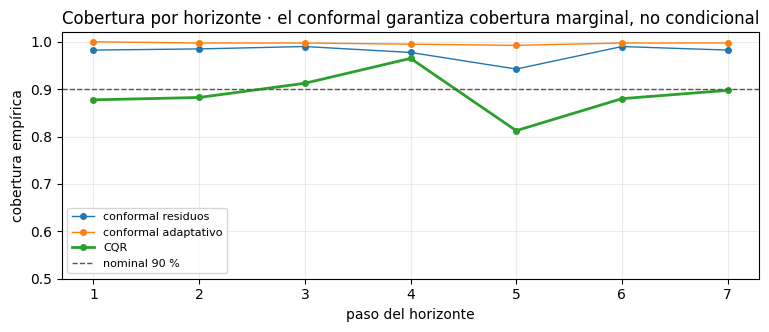

Que la línea cruce el nominal en algunos pasos es exactamente la limitación
declarada: la garantía es marginal. Desagregar es lo que la hace visible.


In [9]:
fig, eje = plt.subplots()
for nombre, valores in por_h.items():
    ancho = 2.0 if nombre == "CQR" else 1.0
    eje.plot(range(1, H + 1), valores, marker="o", ms=4, lw=ancho, label=nombre)
eje.axhline(cfg.FORECAST.coverage, color="#5A5550", ls="--", lw=1, label="nominal 90 %")
eje.set_xlabel("paso del horizonte")
eje.set_ylabel("cobertura empírica")
eje.set_ylim(0.5, 1.02)
eje.set_title("Cobertura por horizonte · el conformal garantiza cobertura marginal, no condicional")
eje.legend(fontsize=8)
plt.show()

print("Que la línea cruce el nominal en algunos pasos es exactamente la limitación")
print("declarada: la garantía es marginal. Desagregar es lo que la hace visible.")

## 4 · Un defecto que vale contar: la orden no salía del cuantil entrenado

El artefacto servido es un conformal envolviendo un LightGBM cuantílico. Su `predict_quantile`
**descartaba los boosters entrenados con pérdida cuantílica** e interpolaba entre los límites del
intervalo. O sea que la cantidad a pedir salía de la forma de la banda conformal y **no** del
cuantil $q^*$.

Importa porque es la frase que sostiene el diferencial del proyecto: «el modelo se entrena con
pérdida cuantílica en ese $q^*$, así que su salida **es** la orden». Para el artefacto servido eso
no era cierto.

Lo difícil de ver era que **la mediana coincidía**: un gráfico de pronóstico central se veía
perfecto. La celda de abajo compara nivel por nivel.

In [10]:
base = cqr.base
del_booster = base.predict_quantile(futuro, cuantiles)

# La banda del conformal de residuos, interpolada como hacía el código anterior.
iv_res = residuos.predict_interval(futuro)
anclas = np.array([alpha / 2, 0.5, 1 - alpha / 2])
trio = np.stack(
    [iv_res["pred_lo"].to_numpy(), iv_res["y_pred"].to_numpy(), iv_res["pred_hi"].to_numpy()], axis=1
)
de_la_banda = {
    quantile_col(q): np.array([np.interp(q, anclas, fila) for fila in trio]) for q in cuantiles
}

comparacion = pd.DataFrame(
    {
        "booster entrenado": [float(del_booster[quantile_col(q)].mean()) for q in cuantiles],
        "derivado de la banda": [float(de_la_banda[quantile_col(q)].mean()) for q in cuantiles],
    },
    index=[f"q{q}" for q in cuantiles],
)
comparacion["Δ %"] = 100 * (comparacion["derivado de la banda"] / comparacion["booster entrenado"] - 1)
display(comparacion.round(4))

q_star = cfg.ECONOMICS.critical_fraction
orden_booster = nv.optimal_order_from_quantiles(del_booster, quantiles=cuantiles, economics=eco).sum()
orden_banda = nv.optimal_order_from_quantiles(
    pd.DataFrame(de_la_banda), quantiles=cuantiles, economics=eco
).sum()
print(f"orden total con el booster de q*={q_star}: {orden_booster:.2f}")
print(f"orden total interpolando la banda        : {orden_banda:.2f}")
print(f"diferencia                               : {(orden_banda / orden_booster - 1) * 100:+.2f} %")
print("\nY el error iba SIEMPRE en la misma dirección, porque la banda está inflada.")

,booster entrenado,derivado de la banda,Δ %
q0.05,0.5782,0.0158,-97.2687
q0.5,1.4040,1.4112,0.5127
q0.625,1.5549,2.4493,57.5248
q0.9,1.9856,4.7334,138.3800
q0.95,2.2320,5.1487,130.6709


orden total con el booster de q*=0.625: 4353.72
orden total interpolando la banda        : 6858.18
diferencia                               : +57.52 %

Y el error iba SIEMPRE en la misma dirección, porque la banda está inflada.


**Cómo quedó.** Cuando el modelo base sabe dar cuantiles, manda el base. El conformal sigue
siendo dueño del **intervalo**, que es para lo que tiene garantía de cobertura. Las dos
responsabilidades quedaron separadas, y mezclarlas fue el defecto. Detalle en `docs/decisiones.md`
D20.

> **Sobre la magnitud.** El número que imprime la celda de arriba es de **esta** corrida: 400
> series, un fold, y el conformal de residuos en su variante no adaptativa. El README y D20
> reportan **21,5 %**, medido sobre 25 series del panel completo con el artefacto que la API
> servía. Las dos mediciones dicen lo mismo en dirección y las dos están en su contexto; el
> tamaño depende de cuánto esté inflada la banda para las series que se miran. Lo que no depende
> del recorte es el signo: la banda interpolada **siempre** pide de más en un $q^*$ por encima de
> la mediana.

## 5 · La tabla de reposición, que es la salida del sistema

Todo lo anterior existe para producir esto: una lista de qué pedir, ordenada por magnitud.

In [11]:
orden = nv.optimal_order_from_quantiles(del_booster, quantiles=cuantiles, economics=eco)
tabla = nv.reorder_table(futuro, orden, economics=eco)

esperanzas = nv.expected_cost_from_quantiles(
    del_booster, quantiles=cuantiles, order=orden, economics=eco
)
tabla = tabla.join(esperanzas[["expected_shortfall", "expected_overage"]].reset_index(drop=True))
display(tabla.head(10).round(4))

print(f"masa de probabilidad por encima del último cuantil: {esperanzas['tail_mass'].iloc[0]:.1%}")
print("Por eso el faltante esperado es una cota inferior, y la API lo declara.")

,series_id,dt,h,store_id,product_id,reorder_qty,critical_fraction,expected_shortfall,expected_overage
0,147_691,2024-06-30,5,147,691,10.5552,0.625,0.0475,0.1332
1,147_691,2024-06-29,4,147,691,10.1764,0.625,0.0851,0.1257
2,147_691,2024-06-26,1,147,691,9.8588,0.625,0.0758,0.1407
3,147_691,2024-06-27,2,147,691,9.5102,0.625,0.0743,0.1044
4,147_691,2024-06-28,3,147,691,9.3424,0.625,0.0756,0.0762
5,147_300,2024-06-26,1,147,300,9.3087,0.625,0.0929,0.0506
6,147_300,2024-06-27,2,147,300,8.9747,0.625,0.0649,0.0940
7,535_70,2024-06-26,1,535,70,8.6347,0.625,0.0818,0.1686
8,147_691,2024-07-02,7,147,691,8.5821,0.625,0.0696,0.1544
9,147_300,2024-06-28,3,147,300,8.5821,0.625,0.0705,0.1660


masa de probabilidad por encima del último cuantil: 5.0%
Por eso el faltante esperado es una cota inferior, y la API lo declara.


## Lo que sale de acá

- El mínimo del costo esperado **cae en $q^*$**, verificado y no afirmado.
- El faltante y el sobrante esperados salen de la distribución que el modelo estima, no de un
  supuesto de forma metido en la capa de presentación.
- El faltante es una **cota inferior** declarada, porque la grilla de cuantiles termina en 0,95.
- **CQR corrige la sobre-cobertura** porque su corrección puede ser negativa, y el conformal de
  residuos absolutos no puede por construcción.
- La cobertura por horizonte muestra la limitación real: la garantía es **marginal**, no
  condicional.
- La orden sale del booster entrenado en $q^*$, no del intervalo. Separar esas dos
  responsabilidades fue el arreglo de D20.

**Sigue:** `06_roi.ipynb` — el impacto económico, sin inventar moneda.